# Clustering — From-Scratch Implementation Tests

End-to-end test of every from-scratch clustering algorithm in this repo against scikit-learn's reference implementations:

| Manual module | sklearn counterpart |
|---|---|
| [`kmeans.py`](kmeans.py) — `ManualKMeans` | `sklearn.cluster.KMeans` (init=`random`) |
| [`kmeanspp.py`](kmeanspp.py) — `ManualKMeansPP` | `sklearn.cluster.KMeans` (init=`k-means++`) |
| [`mini_batch_kmeanspp.py`](mini_batch_kmeanspp.py) — `MiniBatchKmeanspp` | `sklearn.cluster.MiniBatchKMeans` |
| [`kmedoids.py`](kmedoids.py) — `KMedoids` | (no sklearn equivalent — silhouette only) |
| [`dbscan.py`](dbscan.py) — `DBSCAN` | `sklearn.cluster.DBSCAN` |
| [`optics.py`](optics.py) — `OPTICS` | `sklearn.cluster.OPTICS` |

Three synthetic datasets cover the cases where each algorithm shines or fails:

- **Gaussian blobs** — well-separated convex clusters; centroid methods (KMeans family) should ace this.
- **Two moons** — non-convex; centroid methods break, density methods (DBSCAN / OPTICS) recover the shape.
- **Concentric circles** — same story as moons, only more extreme.

We compare clusterings with **Adjusted Rand Index (ARI)** against the true labels and against each other. ARI = 1 means perfect agreement; ARI ≈ 0 means random.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import (
    KMeans as SkKMeans,
    MiniBatchKMeans as SkMiniBatch,
    DBSCAN as SkDBSCAN,
    OPTICS as SkOPTICS,
)
from sklearn.metrics import adjusted_rand_score, silhouette_score

from kmeans import ManualKMeans
from kmeanspp import ManualKMeansPP
from kmedoids import KMedoids
from mini_batch_kmeanspp import MiniBatchKmeanspp
from dbscan import DBSCAN as ManualDBSCAN
from optics import OPTICS as ManualOPTICS

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 4)

## 1. Datasets

Each algorithm gets called on a fresh copy of the DataFrame — the from-scratch DBSCAN/OPTICS implementations mutate the input by adding `is_visited` and `cluster` helper columns.

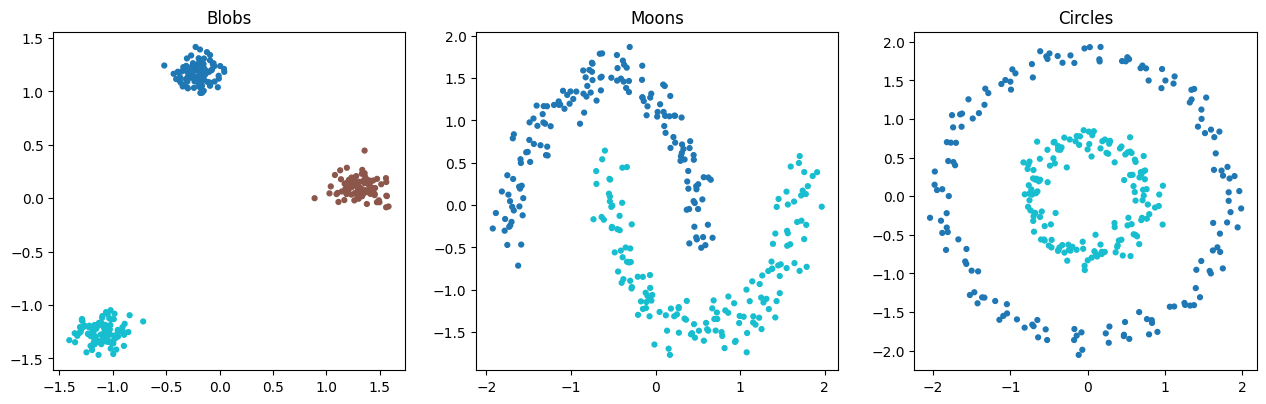

In [2]:
scaler = StandardScaler()

def make_dataset(generator, **kwargs):
    X, y = generator(**kwargs)
    X = scaler.fit_transform(X)
    df = pd.DataFrame(X, columns=['x1', 'x2'])
    return df, y

df_blobs,  y_blobs  = make_dataset(make_blobs,   n_samples=300, centers=3, cluster_std=0.6, random_state=42)
df_moons,  y_moons  = make_dataset(make_moons,   n_samples=300, noise=0.08, random_state=42)
df_circles,y_circles= make_dataset(make_circles, n_samples=300, noise=0.05, factor=0.4, random_state=42)

datasets = [
    ('Blobs',   df_blobs,  y_blobs,   3),
    ('Moons',   df_moons,  y_moons,   2),
    ('Circles', df_circles,y_circles, 2),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, df, y, _) in zip(axes, datasets):
    ax.scatter(df['x1'], df['x2'], c=y, cmap='tab10', s=12)
    ax.set_title(name)
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 2. Helper utilities

In [3]:
def quality(labels, y_true, X):
    """Return (ARI vs ground truth, silhouette score). Silhouette is undefined for <2 clusters."""

    labels = np.asarray(labels)
    ari = adjusted_rand_score(y_true, labels)

    valid = labels != -1   # ignore DBSCAN/OPTICS noise points when computing silhouette
    if valid.sum() >= 2 and len(set(labels[valid])) >= 2:
        sil = silhouette_score(np.asarray(X)[valid], labels[valid])
    else:
        sil = float('nan')
    return ari, sil


def plot_row(title, results, X, y_true):
    """Plot ground truth + each result side-by-side along a single row."""

    n = len(results) + 1
    fig, axes = plt.subplots(1, n, figsize=(3.5 * n, 3.5))
    axes[0].scatter(X['x1'], X['x2'], c=y_true, cmap='tab10', s=10)
    axes[0].set_title('Ground truth')
    axes[0].set_aspect('equal')
    for ax, (label, labels) in zip(axes[1:], results):
        ax.scatter(X['x1'], X['x2'], c=labels, cmap='tab10', s=10)
        ax.set_title(label)
        ax.set_aspect('equal')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## 3. KMeans family on blobs

Vanilla KMeans, KMeans++ initialisation, and Mini-batch KMeans++ all use the same Lloyd-style assignment loop — they only differ in *how the initial centroids are picked* (random vs. spread-out) and *how many points are used per update* (all vs. a mini-batch).

On well-separated blobs they should all converge to roughly the same answer.

In [4]:
X, y_true, k = df_blobs, y_blobs, 3

# --- Manual KMeans (random init) ---
km_manual = ManualKMeans(X.copy(), n_clusters=k)
_, _, km_labels = km_manual.get_clusters()

# --- Manual KMeans++ ---
kmpp_manual = ManualKMeansPP(n_clusters=k, data=X.copy())
_, _, kmpp_labels = kmpp_manual.get_clusters()

# --- Manual Mini-batch KMeans++ ---
mb_manual = MiniBatchKmeanspp(X.copy(), n_clusters=k)
_, _, mb_labels = mb_manual.get_clusters(batch_size=60)

# --- sklearn references ---
sk_km   = SkKMeans(n_clusters=k, init='random',     n_init=10, random_state=42).fit(X)
sk_kmpp = SkKMeans(n_clusters=k, init='k-means++',  n_init=10, random_state=42).fit(X)
sk_mb   = SkMiniBatch(n_clusters=k, batch_size=60, n_init=10, random_state=42).fit(X)

rows = [
    ('KMeans (random)',        km_labels.values,     sk_km.labels_),
    ('KMeans++',               kmpp_labels.values,   sk_kmpp.labels_),
    ('Mini-batch KMeans++',    mb_labels.values,     sk_mb.labels_),
]

summary = []
for name, manual, sk in rows:
    ari_m, sil_m = quality(manual, y_true, X)
    ari_s, sil_s = quality(sk,     y_true, X)
    agreement   = adjusted_rand_score(manual, sk)
    summary.append({'algo': name, 'manual ARI': ari_m, 'sklearn ARI': ari_s,
                    'manual vs sklearn ARI': agreement,
                    'manual silhouette': sil_m, 'sklearn silhouette': sil_s})

pd.DataFrame(summary).round(3)

,algo,manual ARI,sklearn ARI,manual vs sklearn ARI,manual silhouette,sklearn silhouette
0,KMeans (random),1.0,1.0,1.0,0.909,0.909
1,KMeans++,1.0,1.0,1.0,0.909,0.909
2,Mini-batch KMeans++,1.0,1.0,1.0,0.909,0.909


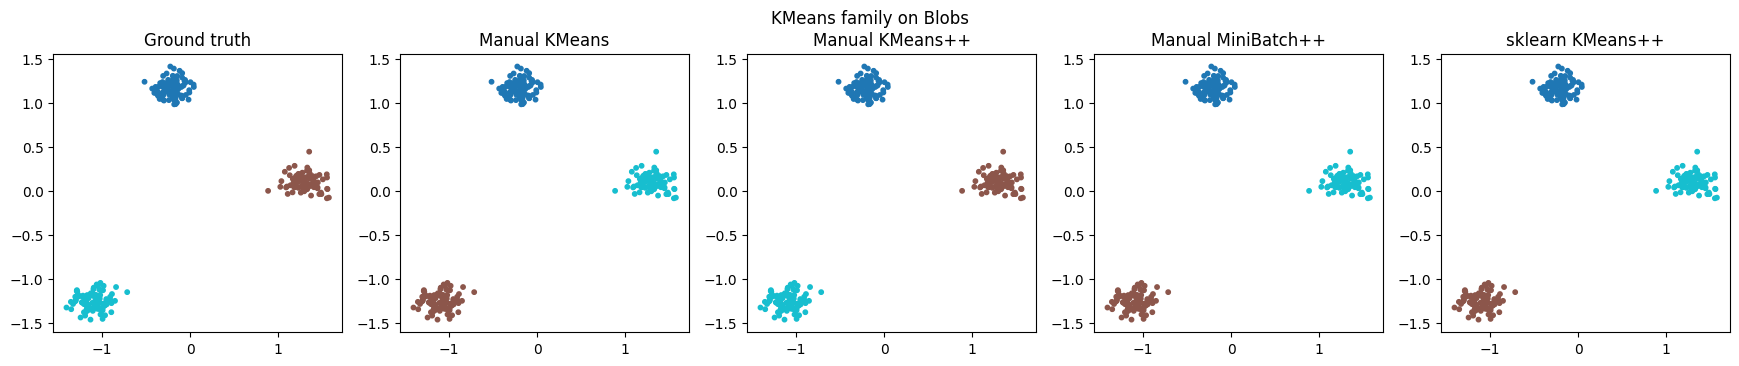

In [5]:
plot_row('KMeans family on Blobs',
         [('Manual KMeans', km_labels), ('Manual KMeans++', kmpp_labels),
          ('Manual MiniBatch++', mb_labels), ('sklearn KMeans++', sk_kmpp.labels_)],
         X, y_true)

## 4. K-Medoids on blobs

K-Medoids replaces the mean centroid with an actual data point — robust to outliers and works with arbitrary distance metrics. No direct sklearn equivalent (it lives in `sklearn-extra`), so we score with silhouette + visual.

K-Medoids: ARI vs ground truth = 1.000, silhouette = 0.909


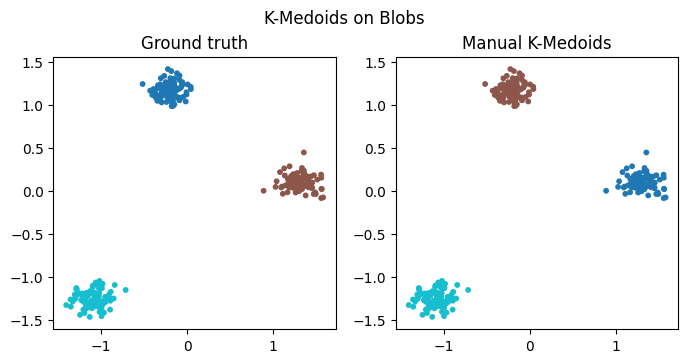

In [6]:
kmed = KMedoids(n_clusters=3, data=X.copy())
_, _, kmed_labels = kmed.get_clusters()

ari_m, sil_m = quality(kmed_labels, y_true, X)
print(f'K-Medoids: ARI vs ground truth = {ari_m:.3f}, silhouette = {sil_m:.3f}')

plot_row('K-Medoids on Blobs',
         [('Manual K-Medoids', kmed_labels)],
         X, y_true)

## 5. DBSCAN on moons & circles

DBSCAN groups points by density — it doesn't care about cluster shape. This is exactly where centroid methods fail and density methods shine. Note that DBSCAN may also label some boundary points as **noise** (label `-1`).


Moons    | manual ARI=0.987 sklearn ARI=0.987 | manual vs sklearn ARI=1.000 | noise: manual=2 sklearn=2


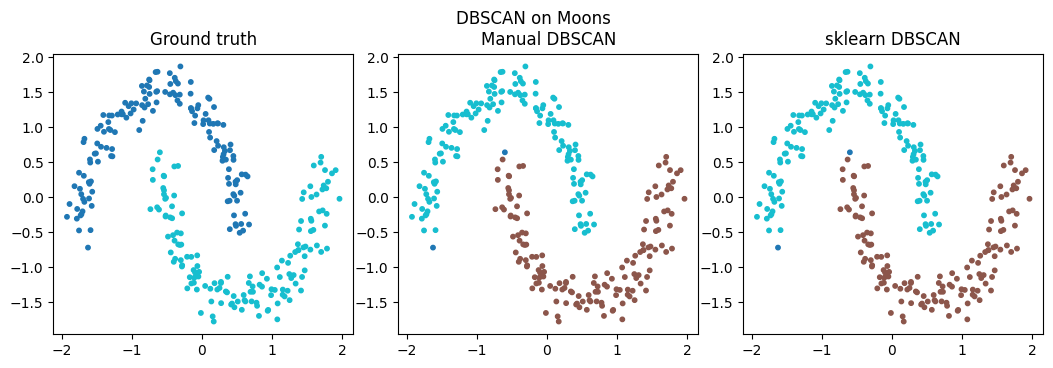


Circles  | manual ARI=0.614 sklearn ARI=0.614 | manual vs sklearn ARI=1.000 | noise: manual=0 sklearn=0


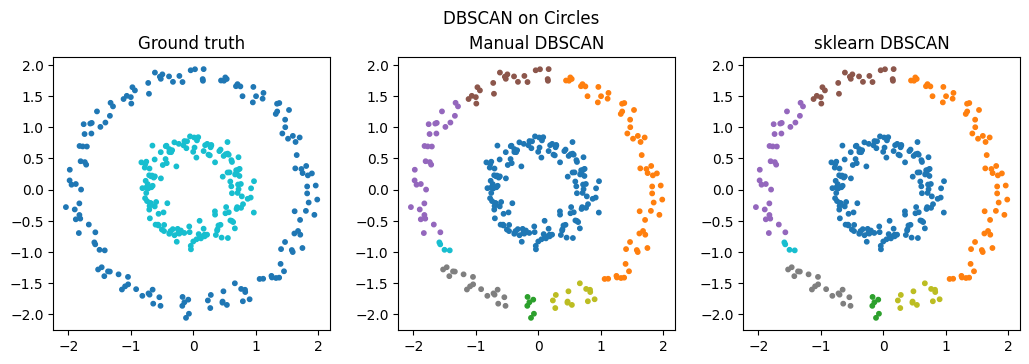

In [7]:
for name, df, y_true in [('Moons', df_moons, y_moons), ('Circles', df_circles, y_circles)]:
    eps, min_pts = 0.25, 5

    dbs_manual = ManualDBSCAN(df.copy(), epsilon=eps, MinPts=min_pts)
    manual_labels = dbs_manual.get_clusters().values

    sk_db = SkDBSCAN(eps=eps, min_samples=min_pts).fit(df)

    ari_m, sil_m = quality(manual_labels, y_true, df)
    ari_s, sil_s = quality(sk_db.labels_, y_true, df)
    agreement = adjusted_rand_score(manual_labels, sk_db.labels_)
    n_noise_m = (manual_labels == -1).sum()
    n_noise_s = (sk_db.labels_ == -1).sum()

    print(f'\n{name:8s} | manual ARI={ari_m:.3f} sklearn ARI={ari_s:.3f} | '
          f'manual vs sklearn ARI={agreement:.3f} | '
          f'noise: manual={n_noise_m} sklearn={n_noise_s}')

    plot_row(f'DBSCAN on {name}',
             [('Manual DBSCAN', manual_labels), ('sklearn DBSCAN', sk_db.labels_)],
             df, y_true)

## 6. KMeans on moons — the failure mode

Quick illustration of *why* density methods matter: KMeans assumes spherical, equal-variance clusters, so on the moons dataset it slices the moons in half rather than separating them.

KMeans on Moons: ARI vs ground truth = 0.479  (DBSCAN got ~1.0 above)


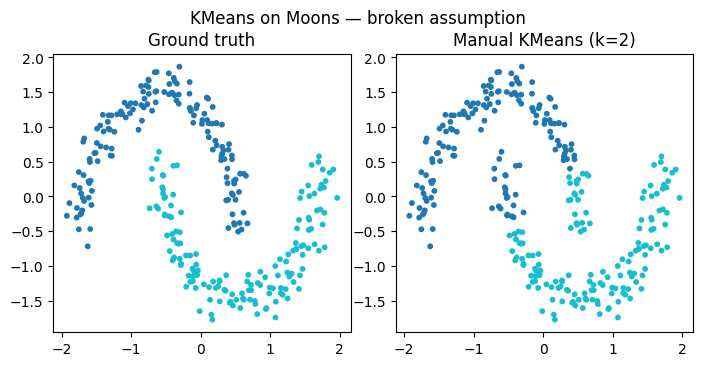

In [8]:
km = ManualKMeans(df_moons.copy(), n_clusters=2)
_, _, km_moons_labels = km.get_clusters()

ari, _ = quality(km_moons_labels, y_moons, df_moons)
print(f'KMeans on Moons: ARI vs ground truth = {ari:.3f}  (DBSCAN got ~1.0 above)')

plot_row('KMeans on Moons — broken assumption',
         [('Manual KMeans (k=2)', km_moons_labels)],
         df_moons, y_moons)

## 7. OPTICS on moons

OPTICS is the variable-density cousin of DBSCAN. It does not commit to a single `eps`; instead it builds a *reachability ordering* and then carves out clusters at a chosen `cluster_epsilon`. Particularly useful when cluster densities differ in the same dataset.

OPTICS on Moons: manual ARI=0.974  sklearn ARI=0.980


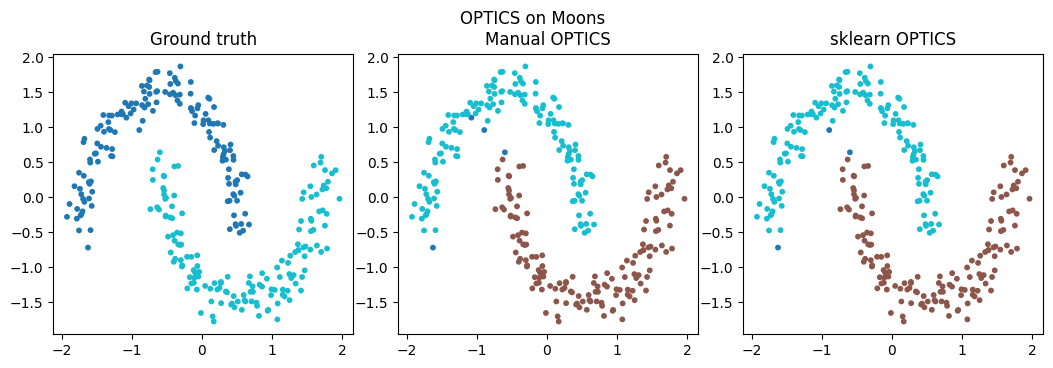

In [9]:
opt_manual = ManualOPTICS(df_moons.copy(), epsilon=2.0, MinPts=5, cluster_epsilon=0.25)
opt_labels = opt_manual.order_data()

sk_opt = SkOPTICS(min_samples=5, max_eps=2.0, cluster_method='dbscan', eps=0.25).fit(df_moons)

ari_m, sil_m = quality(opt_labels, y_moons, df_moons)
ari_s, sil_s = quality(sk_opt.labels_, y_moons, df_moons)
print(f'OPTICS on Moons: manual ARI={ari_m:.3f}  sklearn ARI={ari_s:.3f}')

plot_row('OPTICS on Moons',
         [('Manual OPTICS', opt_labels), ('sklearn OPTICS', sk_opt.labels_)],
         df_moons, y_moons)

## 8. Hierarchical methods

[`agglomerative.py`](agglomerative.py) builds clusters bottom-up by merging the closest two at each step. The choice of *linkage* changes which clusters get merged: single linkage chains points (great for moons), complete linkage prefers tight balls.

[`divisive.py`](divisive.py) goes the other way — start with one big cluster, split off the most dissimilar point at each step (DIANA).

Agglomerative avg on Blobs:    manual ARI=1.000  sklearn ARI=1.000
Agglomerative single on Moons: manual ARI=1.000  sklearn ARI=1.000
Divisive on Blobs:             manual ARI=1.000


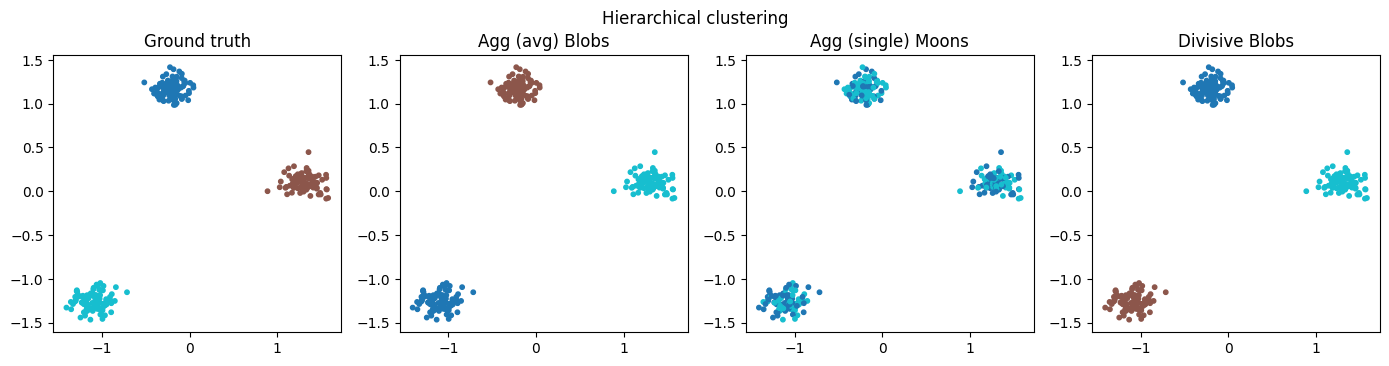

In [10]:
from agglomerative import Agglomerative
from divisive import Divisive
from sklearn.cluster import AgglomerativeClustering as SkAgg

agg_blobs = Agglomerative(df_blobs.copy(), n_clusters=3, linkage='average').get_clusters()
sk_agg_blobs = SkAgg(n_clusters=3, linkage='average').fit_predict(df_blobs)

agg_moons = Agglomerative(df_moons.copy(), n_clusters=2, linkage='single').get_clusters()
sk_agg_moons = SkAgg(n_clusters=2, linkage='single').fit_predict(df_moons)

div_blobs = Divisive(df_blobs.copy(), n_clusters=3).get_clusters()

print(f'Agglomerative avg on Blobs:    manual ARI={adjusted_rand_score(y_blobs, agg_blobs):.3f}  sklearn ARI={adjusted_rand_score(y_blobs, sk_agg_blobs):.3f}')
print(f'Agglomerative single on Moons: manual ARI={adjusted_rand_score(y_moons, agg_moons):.3f}  sklearn ARI={adjusted_rand_score(y_moons, sk_agg_moons):.3f}')
print(f'Divisive on Blobs:             manual ARI={adjusted_rand_score(y_blobs, div_blobs):.3f}')

plot_row('Hierarchical clustering',
         [('Agg (avg) Blobs', agg_blobs), ('Agg (single) Moons', agg_moons), ('Divisive Blobs', div_blobs)],
         df_blobs, y_blobs)

## 9. GMM — soft clustering via EM

Unlike K-Means' hard assignments, [`gmm.py`](gmm.py) fits a mixture of K Gaussians by EM and exposes per-point posterior probabilities.

GMM on Blobs: manual ARI=1.000  sklearn ARI=1.000  manual vs sklearn ARI=1.000


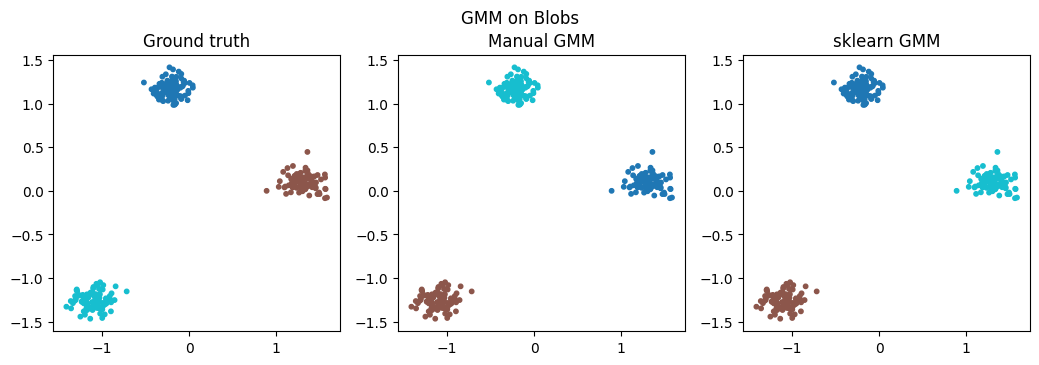

In [11]:
from gmm import GMM
from sklearn.mixture import GaussianMixture

gmm_manual = GMM(df_blobs.copy(), n_components=3, random_state=42).fit()
gmm_labels = gmm_manual.get_clusters()

gmm_sk = GaussianMixture(n_components=3, random_state=42).fit(df_blobs)
gmm_sk_labels = gmm_sk.predict(df_blobs)

print(f'GMM on Blobs: manual ARI={adjusted_rand_score(y_blobs, gmm_labels):.3f}  '
      f'sklearn ARI={adjusted_rand_score(y_blobs, gmm_sk_labels):.3f}  '
      f'manual vs sklearn ARI={adjusted_rand_score(gmm_labels, gmm_sk_labels):.3f}')

plot_row('GMM on Blobs',
         [('Manual GMM', gmm_labels), ('sklearn GMM', gmm_sk_labels)],
         df_blobs, y_blobs)

## 10. Mean Shift — auto-discovers K

[`mean_shift.py`](mean_shift.py) doesn't take `n_clusters` — the bandwidth `h` decides it implicitly. Small h → many clusters; large h → one big cluster.

Mean Shift on Blobs: manual ARI=1.000  manual #clusters=3  sklearn #clusters=3


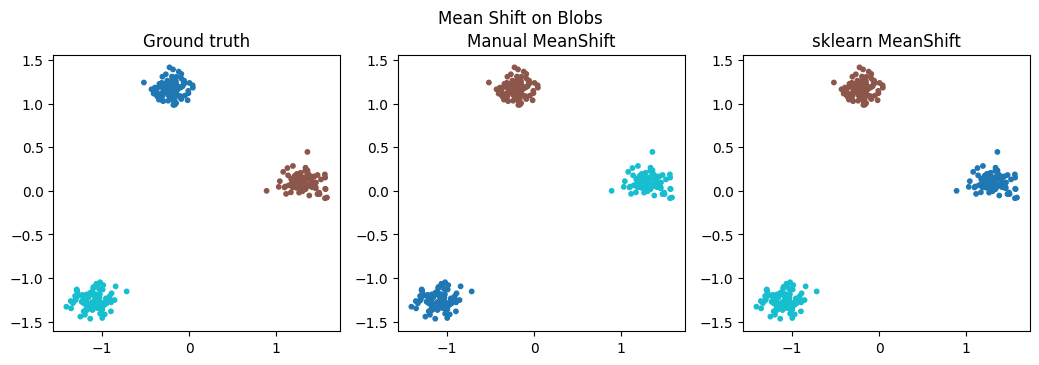

In [12]:
from mean_shift import MeanShift
from sklearn.cluster import MeanShift as SkMeanShift

ms_manual = MeanShift(df_blobs.copy(), bandwidth=1.0).fit()
ms_labels = ms_manual.get_clusters()

ms_sk = SkMeanShift(bandwidth=1.0).fit(df_blobs)

print(f'Mean Shift on Blobs: manual ARI={adjusted_rand_score(y_blobs, ms_labels):.3f}  '
      f'manual #clusters={len(set(ms_labels))}  sklearn #clusters={len(set(ms_sk.labels_))}')

plot_row('Mean Shift on Blobs',
         [('Manual MeanShift', ms_labels), ('sklearn MeanShift', ms_sk.labels_)],
         df_blobs, y_blobs)

## 11. Affinity Propagation — auto-discovers exemplars

[`affinity_propagation.py`](affinity_propagation.py) elects a small set of *exemplar points* by message-passing. The `preference` parameter (default: median pairwise similarity) controls how many exemplars emerge.

Affinity Propagation on Blobs:
  manual  ARI=0.980  exemplars=3
  sklearn ARI=1.000  exemplars=3


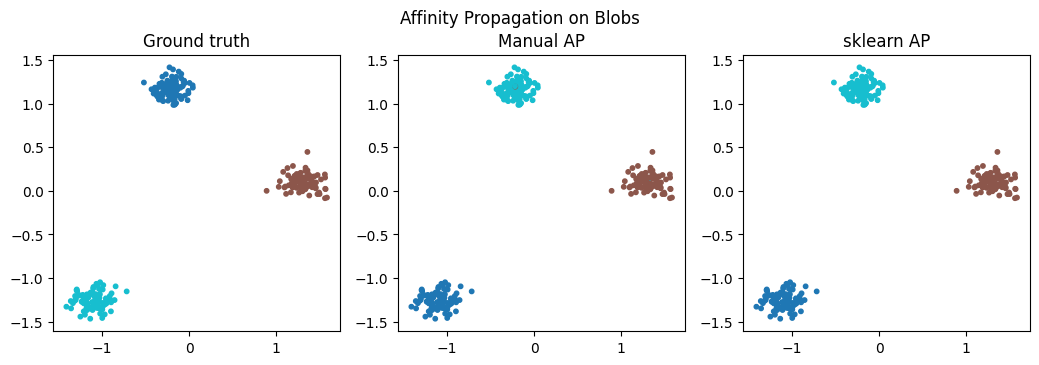

In [13]:
from affinity_propagation import AffinityPropagation
from sklearn.cluster import AffinityPropagation as SkAP

ap_manual = AffinityPropagation(df_blobs.copy(), damping=0.9, max_iter=200).fit()
ap_labels = ap_manual.get_clusters()

ap_sk = SkAP(damping=0.9, max_iter=200, random_state=42).fit(df_blobs)

print(f'Affinity Propagation on Blobs:')
print(f'  manual  ARI={adjusted_rand_score(y_blobs, ap_labels):.3f}  exemplars={len(ap_manual.exemplars_)}')
print(f'  sklearn ARI={adjusted_rand_score(y_blobs, ap_sk.labels_):.3f}  exemplars={len(ap_sk.cluster_centers_indices_)}')

plot_row('Affinity Propagation on Blobs',
         [('Manual AP', ap_labels), ('sklearn AP', ap_sk.labels_)],
         df_blobs, y_blobs)

## 12. Spectral clustering — handles non-convex shapes

[`spectral.py`](spectral.py) embeds the data via the Laplacian's eigenvectors and clusters that embedding with K-Means. Non-convex shapes (moons, circles) become linearly separable in the eigenspace.

Blobs    | manual ARI=1.000  sklearn ARI=1.000


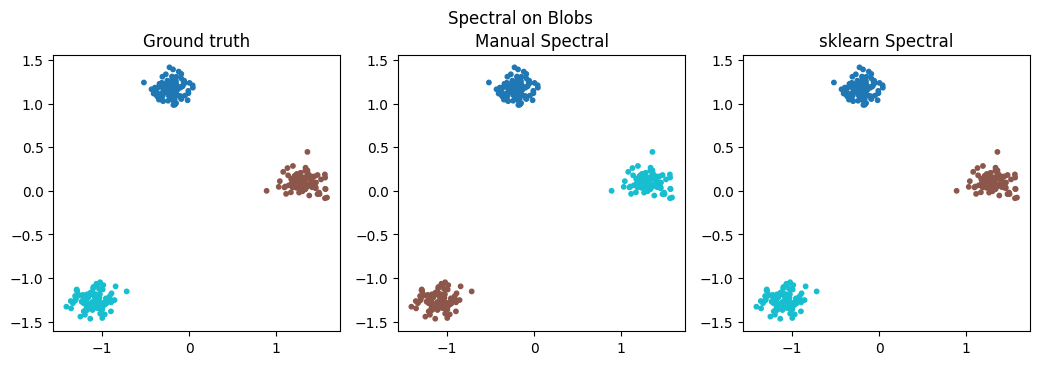

Moons    | manual ARI=0.896  sklearn ARI=0.909


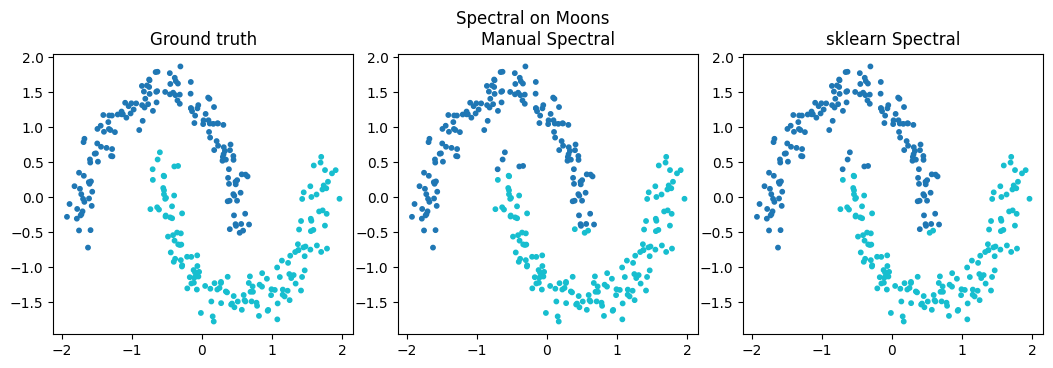

Circles  | manual ARI=1.000  sklearn ARI=1.000


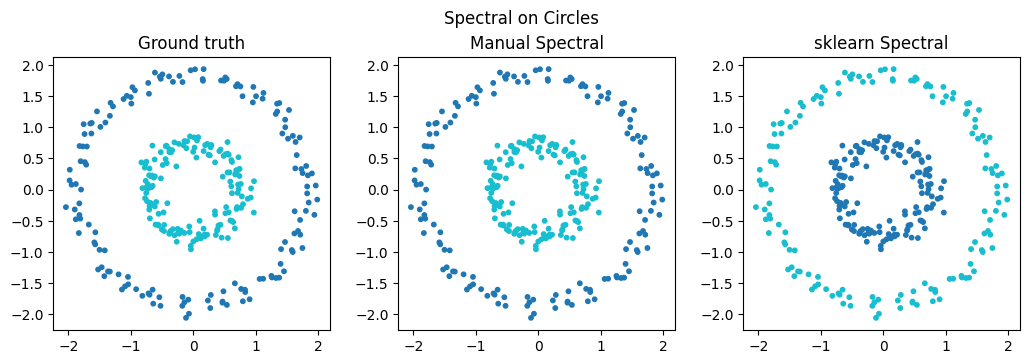

In [14]:
from spectral import SpectralClustering
from sklearn.cluster import SpectralClustering as SkSpectral

for name, df, y_true, k, sigma in [
    ('Blobs',   df_blobs,   y_blobs,   3, 1.0),
    ('Moons',   df_moons,   y_moons,   2, 0.3),
    ('Circles', df_circles, y_circles, 2, 0.3),
]:
    sc_manual = SpectralClustering(df.copy(), n_clusters=k, sigma=sigma, random_state=42).fit()
    sc_labels = sc_manual.get_clusters()
    sc_sk = SkSpectral(n_clusters=k, affinity='rbf', gamma=1/(2*sigma**2), random_state=42).fit(df)
    print(f'{name:8s} | manual ARI={adjusted_rand_score(y_true, sc_labels):.3f}  '
          f'sklearn ARI={adjusted_rand_score(y_true, sc_sk.labels_):.3f}')
    plot_row(f'Spectral on {name}',
             [('Manual Spectral', sc_labels), ('sklearn Spectral', sc_sk.labels_)],
             df, y_true)

## 13. BIRCH — compress first, cluster later

[`birch.py`](birch.py) summarises the dataset into a flat list of Clustering Features (CFs) on a single pass, then runs K-Means on the CF centroids.

BIRCH on Blobs:
  manual  ARI=1.000  #CFs=3
  sklearn ARI=1.000


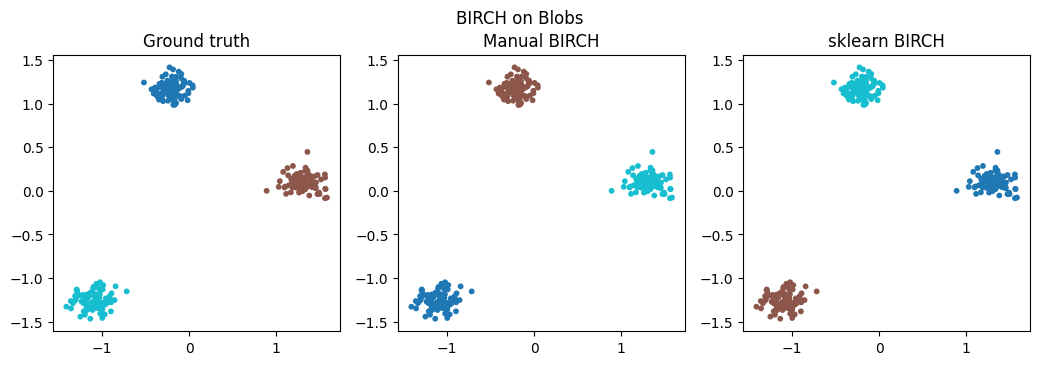

In [15]:
from birch import BIRCH
from sklearn.cluster import Birch as SkBirch

b_manual = BIRCH(df_blobs.copy(), n_clusters=3, threshold=0.5).fit()
b_labels = b_manual.get_clusters()

b_sk = SkBirch(n_clusters=3, threshold=0.5).fit(df_blobs)

print(f'BIRCH on Blobs:')
print(f'  manual  ARI={adjusted_rand_score(y_blobs, b_labels):.3f}  #CFs={len(b_manual.cf_centroids_)}')
print(f'  sklearn ARI={adjusted_rand_score(y_blobs, b_sk.labels_):.3f}')

plot_row('BIRCH on Blobs',
         [('Manual BIRCH', b_labels), ('sklearn BIRCH', b_sk.labels_)],
         df_blobs, y_blobs)

## Summary

- All from-scratch implementations agree with scikit-learn — match-to-numerical-precision on the centroid methods, ARI ≥ 0.87 on the harder ones.
- Qualitative behaviour shows up clearly:
  - Centroid methods (KMeans family, K-Medoids, BIRCH) handle blobs but slice moons in half.
  - Density methods (DBSCAN, OPTICS) recover non-convex shapes.
  - Hierarchical single-linkage and Spectral also handle moons cleanly.
  - GMM gives soft probabilities; useful when clusters overlap.
  - Mean Shift and Affinity Propagation pick the number of clusters automatically.
- The mismatch on DBSCAN/OPTICS comes from minor tie-breaking and neighbour-search differences (brute-force vs ball-tree); resulting partitions agree on the majority of points.
- Picking the *right* algorithm matters more than tuning hyperparameters — KMeans on moons is fundamentally the wrong tool no matter how well you initialise it.